# Funding carry, strategy runs

Runs delta-neutral funding-carry strategies on the C++ engine through the python-callback backtest. A strategy emits target-position Intents, the risk gate turns them into orders and holds autonomous kill authority, and the cost-aware matcher charges the fee, half spread and impact from the cost table.

Predictions come from `results/oof_predictions.parquet`, out of fold and causal, keyed by (symbol, funding ts). Each run is restricted to the window where predictions exist.

## Sim limitations to keep in mind when reading any number here

- Taker only. Every order crosses the spread and pays the taker fee, 4 bps perp and 10 bps spot at VIP0. The sim cannot post a resting limit order, so it never earns the cheaper maker fee. Posting spot passively is the largest available cost saving on the round trip and it is not modelled here.
- No liquidation or margin model. A short-perp squeeze that would liquidate the futures leg is invisible, so tail risk on the short leg is understated.
- Spot microstructure is partial. Spot fee and Amihud impact are real, the spot half spread is a futures-book proxy, no historical spot top-of-book exists to measure it.
- No spot borrow cost and no funding on the spot leg. Only the perp leg pays or receives funding.
- Basis PnL is mark-to-market of the open legs, spot mark minus perp mark. It is in the equity curve, not a separate accrual.
- Fills clear against the cost-aware matcher at one price per order. No partial-fill or slippage dynamics beyond the modelled half spread and impact.
- Cost table in use is whatever `COST_TABLE` points at. The current file predates the real-spot rebuild, treat spot costs as provisional.

In [8]:
import os, sys, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt


def _module_dir():
    d = os.path.abspath(os.getcwd())
    cands = []
    while True:
        cands.append(os.path.join(d, "build", "release"))
        p = os.path.dirname(d)
        if p == d:
            break
        d = p
    cands.append(os.path.expanduser("~/quant-platform/build/release"))
    for c in cands:
        hits = glob.glob(os.path.join(c, "**", "qp_python_backtest*.so"), recursive=True)
        if hits:
            return os.path.dirname(hits[0])
    raise RuntimeError("qp_python_backtest*.so not found; build the target first")


sys.path.insert(0, _module_dir())
import qp_python_backtest as qb

DATA       = os.path.expanduser("~/quant-platform/data/binance_historical")
COST_TABLE = os.path.expanduser("~/quant-platform/data/cost_model/cost_table.csv")

# kSymbols order is the SymbolId, futures venue 0 and spot venue 1.
SYMBOLS = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "BNBUSDT", "XRPUSDT",
           "DOGEUSDT", "ADAUSDT", "LINKUSDT", "AVAXUSDT", "LTCUSDT"]
NAME_TO_ID = {n: i for i, n in enumerate(SYMBOLS)}
ID_TO_NAME = {i: n for n, i in NAME_TO_ID.items()}
FUT, SPOT = 0, 1

oof = pd.read_parquet("results/oof_predictions.parquet")
oof["sid"] = oof["symbol"].map(NAME_TO_ID)
# datetime64[ms, UTC] to integer nanoseconds since epoch, the engine's ts unit.
oof["ts_ns"] = (oof["ts"].dt.tz_convert("UTC").dt.tz_localize(None)
                .values.astype("datetime64[ns]").astype("int64"))

# Runs are restricted to the window where predictions exist. Outside it the
# strategy is blind, and the flat pre-signal stretch only distorts the metrics.
PRED_FIRST = oof["ts"].min().date().isoformat()
PRED_LAST  = oof["ts"].max().date().isoformat()
print("oof rows", len(oof), "window", PRED_FIRST, "to", PRED_LAST)
oof.head(3)

oof rows 22448 window 2022-12-07 to 2024-12-24


,symbol,ts,fold,pred_elastic,pred_gbm,pred_persistence,sid,ts_ns
0,ADAUSDT,2022-12-07 00:00:00+00:00,0,0.001581,0.001363,0.000740,6,1670371200000000000
1,ADAUSDT,2022-12-07 08:00:00+00:00,0,0.000835,0.000978,0.002209,6,1670400000000000000
2,ADAUSDT,2022-12-07 16:00:00+00:00,0,0.001376,0.001189,-0.000694,6,1670428800000000000


## Strategies and risk

Four entry rules, all delta-neutral, spot long and perp short, driven by a prediction looked up at each funding print.

`PredThreshold` opens when the prediction clears a fixed entry level and flattens at or below a fixed exit level.

`PredHysteresis` opens above an entry level, holds through a lower exit band, and flattens only after a minimum number of prints held, so a prediction hovering near the level does not churn.

`PredPartialAdjust` sets an aim size proportional to the prediction over the cost hurdle and moves a fraction of the way to it each print, so the position drifts with the signal instead of snapping on and off.

`PredCrossSectional` ranks the symbols by prediction each print and holds the top few that clear the cost hurdle, choosing which symbols to be in rather than judging each on its own.

`SimpleRiskGate` sizes each intent against the current position, clamps to a per-instrument cap, and flattens every tracked leg once equity falls a set amount off its peak.

In [9]:
class PredThreshold:
    """Open when the prediction clears `enter`, flatten at or below `exit`,
    hold in between. One prediction lookup per funding event."""

    def __init__(self, bt, pred, qty=1.0, enter=0.0034, exit=0.0):
        self.bt = bt
        self.pred = pred
        self.qty = qty
        self.enter = enter
        self.exit = exit
        self.hits = 0
        self.misses = 0

    def on_event(self, ev):
        if ev.kind != qb.EventKind.Funding or ev.venue != FUT:
            return None
        p = self.pred.get((ev.symbol, ev.ts))
        if p is None:
            self.misses += 1
            return None
        self.hits += 1
        held = self.bt.position(ev.symbol, SPOT)
        if p >= self.enter:
            target = self.qty
        elif p <= self.exit:
            target = 0.0
        else:
            target = held
        return [qb.Intent(ev.symbol, SPOT, target),
                qb.Intent(ev.symbol, FUT, -target)]

    def on_timer(self, now):
        return None


class PredHysteresis:
    """Open above `enter`, hold while above `exit`, flatten below `exit` but
    only after `min_hold` prints in the position. One lookup per funding
    event."""

    def __init__(self, bt, pred, qty=1.0, enter=0.0044, exit=0.0017, min_hold=3):
        self.bt = bt
        self.pred = pred
        self.qty = qty
        self.enter = enter
        self.exit = exit
        self.min_hold = min_hold
        self.held = {}          # sid -> prints held since entry
        self.hits = 0
        self.misses = 0

    def on_event(self, ev):
        if ev.kind != qb.EventKind.Funding or ev.venue != FUT:
            return None
        p = self.pred.get((ev.symbol, ev.ts))
        if p is None:
            self.misses += 1
            return None
        self.hits += 1
        in_pos = self.bt.position(ev.symbol, SPOT) > 0
        if in_pos:
            n = self.held.get(ev.symbol, 0) + 1
            self.held[ev.symbol] = n
            if p <= self.exit and n >= self.min_hold:
                target = 0.0
                self.held[ev.symbol] = 0
            else:
                target = self.qty
        elif p >= self.enter:
            target = self.qty
            self.held[ev.symbol] = 0
        else:
            target = 0.0
        return [qb.Intent(ev.symbol, SPOT, target),
                qb.Intent(ev.symbol, FUT, -target)]

    def on_timer(self, now):
        return None


class PredPartialAdjust:
    """Aim size proportional to the prediction over the cost hurdle, capped,
    moved a fraction of the way each funding print. One lookup per event."""

    def __init__(self, bt, pred, hurdle=0.0034, cap=2.0, adjust=0.25):
        self.bt = bt
        self.pred = pred
        self.hurdle = hurdle
        self.cap = cap
        self.adjust = adjust
        self.hits = 0
        self.misses = 0

    def on_event(self, ev):
        if ev.kind != qb.EventKind.Funding or ev.venue != FUT:
            return None
        p = self.pred.get((ev.symbol, ev.ts))
        if p is None:
            self.misses += 1
            return None
        self.hits += 1
        aim = float(np.clip(p / self.hurdle, 0.0, self.cap))
        cur = self.bt.position(ev.symbol, SPOT)
        target = cur + self.adjust * (aim - cur)
        return [qb.Intent(ev.symbol, SPOT, target),
                qb.Intent(ev.symbol, FUT, -target)]

    def on_timer(self, now):
        return None


class PredCrossSectional:
    """Rank symbols by prediction at each print, hold the top `top_n` that
    clear the hurdle at one unit each, flatten the rest."""

    def __init__(self, bt, pred, sids, qty=1.0, hurdle=0.0034, top_n=3):
        self.bt = bt
        self.pred = pred
        self.sids = sids
        self.qty = qty
        self.hurdle = hurdle
        self.top_n = top_n
        self.hits = 0
        self.misses = 0

    def on_event(self, ev):
        if ev.kind != qb.EventKind.Funding or ev.venue != FUT:
            return None
        ts = ev.ts
        eligible = [(self.pred[(s, ts)], s) for s in self.sids
                    if (s, ts) in self.pred and self.pred[(s, ts)] >= self.hurdle]
        eligible.sort(reverse=True)
        top = {s for _, s in eligible[:self.top_n]}
        p = self.pred.get((ev.symbol, ts))
        if p is None:
            self.misses += 1
            return None
        self.hits += 1
        target = self.qty if ev.symbol in top else 0.0
        return [qb.Intent(ev.symbol, SPOT, target),
                qb.Intent(ev.symbol, FUT, -target)]

    def on_timer(self, now):
        return None


class SimpleRiskGate:
    """Per-(symbol, venue) exposure cap plus an equity-drawdown kill switch."""

    def __init__(self, bt, tracked, max_position_qty=10.0, max_drawdown=1e12):
        self.bt = bt
        self.tracked = tracked
        self.max_position_qty = max_position_qty
        self.max_drawdown = max_drawdown
        self._id = 1
        self._peak = 0.0
        self._tripped = False

    def _next(self):
        i = self._id
        self._id += 1
        return i

    def check(self, intent):
        if self._tripped:
            return qb.RiskDecision(qb.RiskOutcome.Rejected, None)
        current = self.bt.position(intent.symbol, intent.venue)
        target = float(np.clip(intent.target_position,
                               -self.max_position_qty, self.max_position_qty))
        delta = target - current
        outcome = (qb.RiskOutcome.Approved if target == intent.target_position
                   else qb.RiskOutcome.Resized)
        side = qb.Side.Buy if delta >= 0 else qb.Side.Sell
        order = qb.Order(self._next(), intent.symbol, side, intent.venue, abs(delta))
        return qb.RiskDecision(outcome, order)

    def on_tick(self):
        eq = self.bt.equity()
        self._peak = max(self._peak, eq)
        if self._tripped or self._peak - eq < self.max_drawdown:
            return None
        self._tripped = True
        orders = []
        for sid, venue in self.tracked:
            pos = self.bt.position(sid, venue)
            if pos == 0.0:
                continue
            side = qb.Side.Sell if pos > 0 else qb.Side.Buy
            orders.append(qb.Order(self._next(), sid, side, venue, abs(pos)))
        return orders

In [10]:
RUNS_PATH = "results/carry_v2_runs.parquet"


def pred_map(col, symbols):
    sids = {NAME_TO_ID[s] for s in symbols}
    d = oof[oof["sid"].isin(sids)]
    return dict(zip(zip(d["sid"], d["ts_ns"]), d[col]))


def run_backtest(symbols, make_strategy, cost_table=COST_TABLE,
                 max_position_qty=10.0, max_drawdown=1e12,
                 event_kinds=(qb.EventKind.Funding,),
                 first=PRED_FIRST, last=PRED_LAST):
    """Wire one strategy and a risk gate onto a fresh engine, run, return
    equity series and per-symbol attribution."""
    ds = qb.Dataset(DATA, symbols, first, last, cost_table or "")
    bt = qb.PythonBacktest(ds)
    strat = make_strategy(bt)
    tracked = [(NAME_TO_ID[s], v) for s in symbols for v in (FUT, SPOT)]
    gate = SimpleRiskGate(bt, tracked, max_position_qty, max_drawdown)
    bt.set_on_event(strat.on_event)
    bt.set_on_timer(strat.on_timer)
    bt.set_check(gate.check)
    # Only funding events reach python on_event, the strategies act on
    # nothing else. Skips a per-kline GIL crossing across every symbol.
    bt.set_event_kinds(list(event_kinds))
    # on_tick fires every event, wire it only when the drawdown kill switch
    # is armed. An unarmed gate would pay that GIL cost for nothing.
    if max_drawdown < 1e12:
        bt.set_on_tick(gate.on_tick)
    res = bt.run()

    eq = pd.DataFrame({"ts": pd.to_datetime([p.ts for p in res.equity_series],
                                            utc=True),
                       "equity": [p.equity for p in res.equity_series]})
    attr = pd.DataFrame({
        "symbol": [ID_TO_NAME[s] for s in res.symbol_ids],
        "fees": res.fees,
        "funding_received": res.funding_received,
        "funding_paid": res.funding_paid,
        "basis_pnl": res.basis_pnl,
    }).set_index("symbol")
    return {"equity": eq, "attr": attr, "final_equity": res.final_equity,
            "strat": strat, "gate": gate}


def daily_sharpe(eq):
    d = eq.set_index("ts")["equity"].resample("1D").last().ffill().diff().dropna()
    return (d.mean() / d.std()) * np.sqrt(365) if d.std() else 0.0


def year_pnl(eq, year):
    e = eq.set_index("ts")["equity"]
    seg = e[e.index.year == year]
    return float(seg.iloc[-1] - seg.iloc[0]) if len(seg) > 1 else 0.0


def log_run(run_id, params, out):
    row = {"run_id": run_id, **params,
           "final_equity": out["final_equity"],
           "sharpe_daily": daily_sharpe(out["equity"]),
           "fees": out["attr"]["fees"].sum(),
           "funding_net": (out["attr"]["funding_received"].sum()
                           - out["attr"]["funding_paid"].sum())}
    df = pd.DataFrame([row])
    if os.path.exists(RUNS_PATH):
        prior = pd.read_parquet(RUNS_PATH)
        prior = prior[prior["run_id"] != run_id]
        df = pd.concat([prior, df], ignore_index=True)
    df.to_parquet(RUNS_PATH, index=False)
    return row


def compare(runs, title):
    rows = []
    for name, o in runs.items():
        rows.append({"model": name,
                     "final_pnl": o["final_equity"],
                     "sharpe": daily_sharpe(o["equity"]),
                     "fees": o["attr"]["fees"].sum(),
                     "funding_net": (o["attr"]["funding_received"].sum()
                                     - o["attr"]["funding_paid"].sum()),
                     "pnl_2023": year_pnl(o["equity"], 2023),
                     "pnl_2024": year_pnl(o["equity"], 2024)})
    tbl = pd.DataFrame(rows).set_index("model").round(2)
    plt.figure(figsize=(11, 4))
    for name, o in runs.items():
        plt.plot(o["equity"]["ts"], o["equity"]["equity"], label=name)
    plt.axhline(0, color="k", lw=0.7); plt.legend()
    plt.ylabel("equity (PnL, USDT)"); plt.title(title)
    plt.show()
    return tbl

SOURCES = ["pred_persistence", "pred_elastic", "pred_gbm"]

## Fixed threshold

Each prediction source drives the fixed-level rule on the same window and cost. The entry level is 34 bps of cumulative funding, the round-trip cost of both legs at taker fees, so a position opens only when the predicted carry covers the cost of putting it on. The exit level is zero, so a position is held while the prediction stays positive.

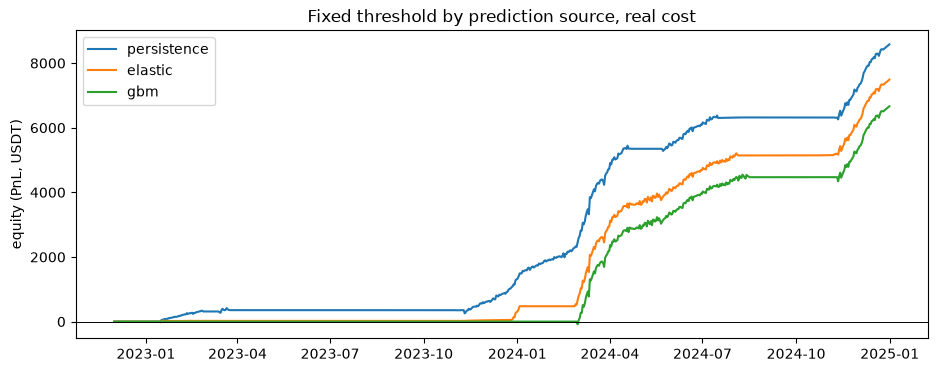

,final_pnl,sharpe,fees,funding_net,pnl_2023,pnl_2024
model,,,,,,
persistence,8579.97,4.97,380.14,8684.30,1308.67,7249.98
elastic,7489.04,4.15,275.65,7385.65,295.04,7172.80
gbm,6664.45,3.66,171.30,6642.23,0.00,6664.08


In [11]:
ENTER, EXIT = 0.0034, 0.0

thr = {}
for col in SOURCES:
    pm = pred_map(col, SYMBOLS)
    o = run_backtest(SYMBOLS, lambda bt, pm=pm: PredThreshold(bt, pm, 1.0, ENTER, EXIT))
    thr[col.replace("pred_", "")] = o
    log_run(f"threshold_{col.replace('pred_', '')}",
            {"rule": "threshold", "pred_col": col, "enter": ENTER, "exit": EXIT}, o)

display(compare(thr, "Fixed threshold by prediction source, real cost"))

All three profitable. Sharpe is suspiciously high, but pnl is positive. This is all funding harvested, and almost all of it in 2024, the high funding bull run. The window starts December 2022, a month after FTX, so this is not the FTX blowup. ALthough it doesn't look like we ever really dip below zero, there is simply a lot of nothing in bear market.

GBM made no money in 2023, interesting. Elastic still picked some up.

## Hysteresis with per-model thresholds

Each prediction source drives the hysteresis rule with entry and exit levels set from its own prediction quantiles, so the sources trade at comparable frequency rather than being judged at one absolute level. Entry is the 90th percentile of that source's predictions, exit the 60th, minimum hold three prints.

per-model (enter, exit) levels: {'persistence': (0.0044, 0.0024), 'elastic': (0.0034, 0.0015), 'gbm': (0.0032, 0.0016)}


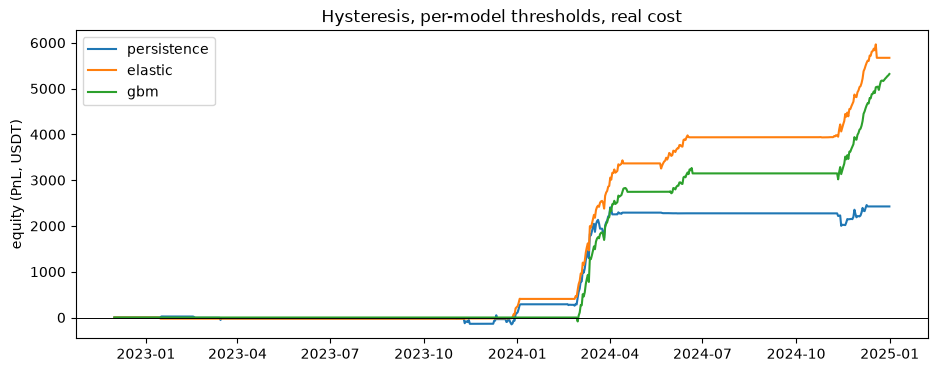

,final_pnl,sharpe,fees,funding_net,pnl_2023,pnl_2024
model,,,,,,
persistence,2425.34,1.68,2541.31,4448.80,93.05,2311.32
elastic,5671.10,3.50,495.07,5958.79,225.92,5424.34
gbm,5317.77,3.43,289.72,5474.80,0.00,5317.77


In [12]:
ENTER_Q, EXIT_Q, MIN_HOLD = 0.90, 0.60, 3

hyst = {}
levels = {}
for col in SOURCES:
    pm = pred_map(col, SYMBOLS)
    enter = float(oof[col].quantile(ENTER_Q))
    exit = float(oof[col].quantile(EXIT_Q))
    levels[col.replace("pred_", "")] = (round(enter, 4), round(exit, 4))
    o = run_backtest(SYMBOLS,
                     lambda bt, pm=pm, e=enter, x=exit: PredHysteresis(bt, pm, 1.0, e, x, MIN_HOLD))
    hyst[col.replace("pred_", "")] = o
    log_run(f"hysteresis_{col.replace('pred_', '')}",
            {"rule": "hysteresis", "pred_col": col, "enter": enter, "exit": exit,
             "min_hold": MIN_HOLD}, o)

print("per-model (enter, exit) levels:", levels)
display(compare(hyst, "Hysteresis, per-model thresholds, real cost"))

All worse than fixed, every source. The positive exit is the culprit. It bails while funding is still positive and then waits for a high bar to get back in, so we sit out a chunk of positive funding. And every wiggle down through the exit is a close then a reopen, so fees pile up.

Persistence gets it from both sides, fees 380 to 2541 and funding roughly halved. It churns itself to death on its own noise, even dips negative in 2023 where the bear churn costs more than it makes.

Per model thresholds flip the ranking, elastic and gbm now beat persistence, but nobody actually improved, persistence just got wrecked. min_hold at 3 is too short to stop it.

## Hysteresis exit and hold sweep

Entry stays at each source's 90th percentile. The exit sweeps from half the entry level down to zero against a minimum hold of 6, 12 and 24 prints. Exit at zero holds a position while the prediction stays positive, the lowest-turnover end. Read Sharpe and PnL alongside fees to see where turnover stops paying.

In [13]:
EXIT_FRACS = [0.5, 0.25, 0.0]
MIN_HOLDS  = [6, 12, 24]

sweep_rows = []
for col in SOURCES:
    name  = col.replace("pred_", "")
    pm    = pred_map(col, SYMBOLS)
    enter = float(oof[col].quantile(0.90))
    for ef in EXIT_FRACS:
        for mh in MIN_HOLDS:
            o = run_backtest(
                SYMBOLS,
                lambda bt, pm=pm, e=enter, x=enter * ef, mh=mh:
                    PredHysteresis(bt, pm, 1.0, e, x, mh))
            sweep_rows.append({"model": name, "exit_frac": ef, "min_hold": mh,
                               "pnl": round(o["final_equity"], 1),
                               "sharpe": round(daily_sharpe(o["equity"]), 2),
                               "fees": round(o["attr"]["fees"].sum(), 1)})

sweep = pd.DataFrame(sweep_rows)
for name in [c.replace("pred_", "") for c in SOURCES]:
    sub = sweep[sweep["model"] == name]
    print(f"\n=== {name} ===  (rows min_hold, cols exit_frac)")
    print("Sharpe"); display(sub.pivot(index="min_hold", columns="exit_frac", values="sharpe"))
    print("PnL");    display(sub.pivot(index="min_hold", columns="exit_frac", values="pnl"))
    print("fees");   display(sub.pivot(index="min_hold", columns="exit_frac", values="fees"))


=== persistence ===  (rows min_hold, cols exit_frac)
Sharpe


exit_frac,0.00,0.25,0.50
min_hold,,,
6,4.71,4.31,4.17
12,4.70,4.31,4.18
24,4.71,4.32,4.18


PnL


exit_frac,0.00,0.25,0.50
min_hold,,,
6,7687.6,6829.1,6516.5
12,7683.8,6855.6,6544.8
24,7695.6,6876.7,6562.1


fees


...

exit_frac,0.00,0.25,0.50
min_hold,,,
6,3.66,3.66,3.49
12,3.66,3.66,3.49
24,3.66,3.66,3.49


PnL


exit_frac,0.00,0.25,0.50
min_hold,,,
6,6665.9,6034.9,5435.6
12,6665.9,6034.9,5438.1
24,6664.4,6035.0,5437.6


fees


exit_frac,0.00,0.25,0.50
min_hold,,,
6,171.3,288.5,286.3
12,171.3,288.5,286.2
24,170.2,287.5,286.2


Pushing exit toward zero just walks back to the fixed rule. At exit zero you hold while funding is positive, which is the fixed threshold, and for elastic the numbers land right on it. Nudge the hold up and it's a touch better, you ride through brief dips instead of bailing. Any positive exit is worse, more churn and less funding.

So hysteresis has no edge here. Low turnover wins, holding while funding is positive is the ceiling.

## Partial adjustment

Aim size proportional to the prediction over the cost hurdle, capped at two units. Each funding print moves a quarter of the way to the aim rather than jumping straight to it, so the position drifts with the signal.

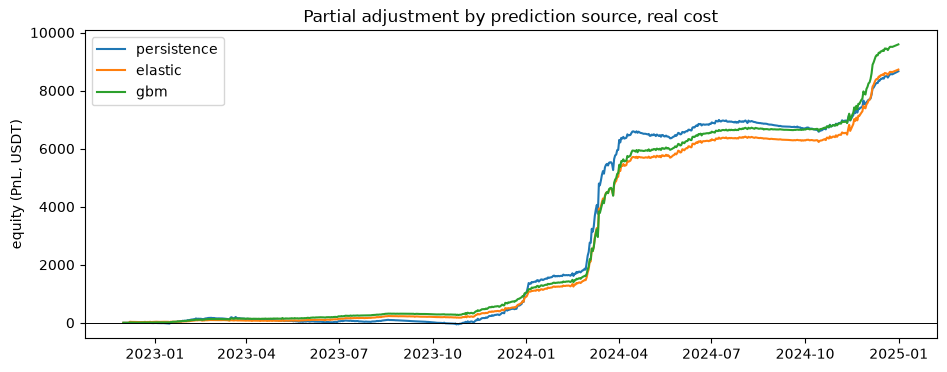

,final_pnl,sharpe,fees,funding_net,pnl_2023,pnl_2024
model,,,,,,
persistence,8665.23,3.37,3685.79,11920.44,1020.59,7607.59
elastic,8724.18,3.76,2072.66,10343.88,854.73,7814.79
gbm,9591.82,4.12,1484.61,10630.61,1017.56,8545.41


In [14]:
HURDLE, CAP, ADJUST = 0.0034, 2.0, 0.25

part = {}
for col in SOURCES:
    pm = pred_map(col, SYMBOLS)
    o = run_backtest(SYMBOLS,
                     lambda bt, pm=pm: PredPartialAdjust(bt, pm, HURDLE, CAP, ADJUST))
    part[col.replace("pred_", "")] = o
    log_run(f"partial_{col.replace('pred_', '')}",
            {"rule": "partial", "pred_col": col, "hurdle": HURDLE,
             "cap": CAP, "adjust": ADJUST}, o)

display(compare(part, "Partial adjustment by prediction source, real cost"))

More money than fixed, all three, and the ranking flips. gbm wins now, then elastic, then persistence, the reverse of fixed. Scaling size with the signal grabs a lot more funding, net funding jumps to 10 to 12k, you hold bigger when the signal is strong and still hold something through the middle where the threshold rules sat flat. gbm even makes money in 2023 now.

But the constant nudging costs. Fees blow up to 1500 to 3700 and Sharpe drops across the board, more turnover means more wobble. gbm wins because it is the smoothest signal, it drifts the least so it churns the least while still catching the funding. More money, less clean.

## Partial adjustment size and speed sweep

Holds the hurdle and sweeps the aim cap over one, two and four units against the adjustment fraction from a slow 0.15 up to a full 1.0. At 1.0 the position snaps straight to the aim, lower fractions drift toward it. Read Sharpe and PnL with fees, the trade is funding captured against turnover.

In [15]:
CAPS    = [1.0, 2.0, 4.0]
ADJUSTS = [0.15, 0.5, 1.0]

psweep_rows = []
for col in SOURCES:
    name = col.replace("pred_", "")
    pm   = pred_map(col, SYMBOLS)
    for cap in CAPS:
        for adj in ADJUSTS:
            o = run_backtest(
                SYMBOLS,
                lambda bt, pm=pm, cap=cap, adj=adj:
                    PredPartialAdjust(bt, pm, 0.0034, cap, adj))
            psweep_rows.append({"model": name, "cap": cap, "adjust": adj,
                                "pnl": round(o["final_equity"], 1),
                                "sharpe": round(daily_sharpe(o["equity"]), 2),
                                "fees": round(o["attr"]["fees"].sum(), 1)})

psweep = pd.DataFrame(psweep_rows)
for name in [c.replace("pred_", "") for c in SOURCES]:
    sub = psweep[psweep["model"] == name]
    print(f"\n=== {name} ===  (rows adjust, cols cap)")
    print("Sharpe"); display(sub.pivot(index="adjust", columns="cap", values="sharpe"))
    print("PnL");    display(sub.pivot(index="adjust", columns="cap", values="pnl"))
    print("fees");   display(sub.pivot(index="adjust", columns="cap", values="fees"))


=== persistence ===  (rows adjust, cols cap)
Sharpe


cap,1.0,2.0,4.0
adjust,,,
0.15,4.51,3.82,3.27
0.50,2.66,2.24,1.77
1.00,-0.35,-0.44,-0.89


PnL


cap,1.0,2.0,4.0
adjust,,,
0.15,7182.8,9679.3,11548.9
0.50,4365.4,5867.6,6445.0
1.00,-626.4,-1208.4,-3129.0


fees


...

cap,1.0,2.0,4.0
adjust,,,
0.15,4.83,4.26,4.25
0.50,4.34,3.76,3.75
1.00,3.27,2.77,2.76


PnL


cap,1.0,2.0,4.0
adjust,,,
0.15,7676.7,9815.6,9867.5
0.50,6969.7,8806.0,8836.5
1.00,5326.4,6479.9,6502.2


fees


cap,1.0,2.0,4.0
adjust,,,
0.15,649.1,1071.0,1121.2
0.50,1529.7,2514.7,2677.3
1.00,3223.3,5012.4,5300.4


Slow wins. The adjustment fraction is the whole game. Drift in at 0.15 and it is great, snap straight to the aim at 1.0 and fees eat everything, persistence even goes negative. That is the point of partial adjustment, the slow drift keeps turnover down, so more of it is better.

Cap trades money for smoothness. A bigger cap grabs more funding so more pnl, but bigger positions churn more so lower Sharpe and higher fees. Best Sharpe is the small slow corner, cap 1 adjust 0.15. Best pnl is cap 4 adjust 0.15.

gbm wins every cell, it is the smoothest signal so it drifts and churns the least. The 0.25 default was fine, 0.15 is better.

## Cross-sectional selection

At each funding print rank the symbols by prediction and hold the top three that clear the cost hurdle, one unit each, flatten the rest. Picks which symbols to be in rather than judging each on its own.

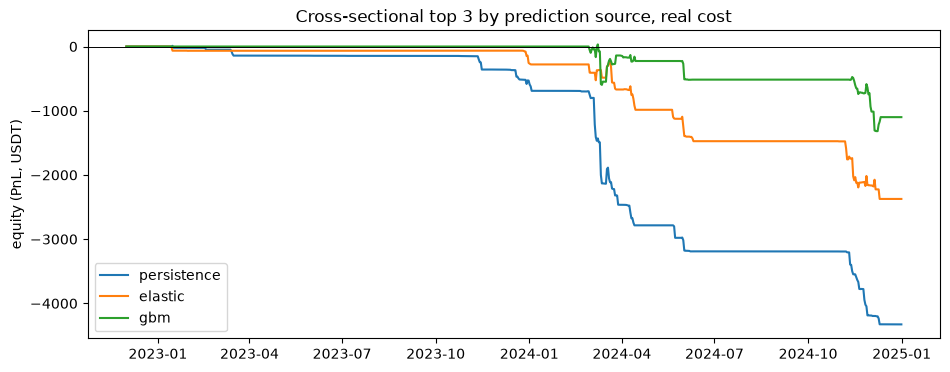

,final_pnl,sharpe,fees,funding_net,pnl_2023,pnl_2024
model,,,,,,
persistence,-4327.46,-3.22,5310.16,1117.86,-530.24,-3736.27
elastic,-2373.82,-2.21,4096.81,1149.24,-256.46,-2106.20
gbm,-1099.94,-0.92,3476.85,1339.26,0.00,-1099.94


In [16]:
SIDS = [NAME_TO_ID[s] for s in SYMBOLS]
HURDLE_X, TOP_N = 0.0034, 3

xsect = {}
for col in SOURCES:
    pm = pred_map(col, SYMBOLS)
    o = run_backtest(SYMBOLS,
                     lambda bt, pm=pm: PredCrossSectional(bt, pm, SIDS, 1.0, HURDLE_X, TOP_N))
    xsect[col.replace("pred_", "")] = o
    log_run(f"xsect_{col.replace('pred_', '')}",
            {"rule": "xsect", "pred_col": col, "hurdle": HURDLE_X, "top_n": TOP_N}, o)

display(compare(xsect, "Cross-sectional top 3 by prediction source, real cost"))

Disaster, all three lose money. Top 3 by predicted size rotates constantly and two things go wrong.

Fees explode, 3500 to 5300, because the top 3 set keeps changing and every change is a close and a reopen.

And funding collapses to about a grand, because the edge is basically BTC and it keeps getting bumped out of the top 3 whenever an alt prediction spikes. Per symbol, BTC funding is 1074 here against 6974 when we just hold it, we miss most of it.

So we pay to rotate and miss the one name that actually pays. Ranking symbols by predicted funding is the wrong move when the funding sits in one name, you want to sit in BTC not rotate around it.

## Notional sizing

Threshold entry, but each leg is sized to a fixed dollar notional through the live mark instead of one raw unit per symbol, and capped so a position's impact stays inside a few bp. This fixes the distortion where one unit meant 27k of BTC against a few cents of DOGE. Fraction of equity becomes a fixed notional here because the sim tracks PnL not a funded balance, and the inverse-vol scaling is left off for now.

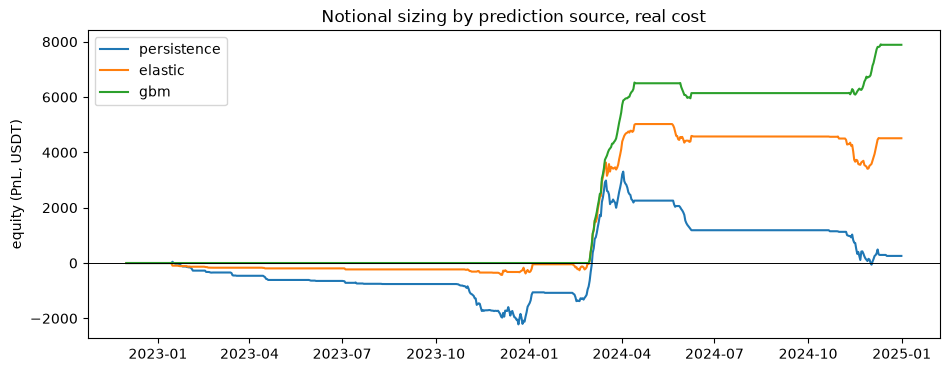

,final_pnl,sharpe,fees,funding_net,pnl_2023,pnl_2024
model,,,,,,
persistence,256.88,0.10,14432.33,12320.15,-1513.58,1706.26
elastic,4510.44,1.94,7921.01,10863.71,-314.50,4838.24
gbm,7889.10,4.06,3284.34,9895.09,0.00,7889.10


In [17]:
NOTIONAL, BUDGET_BPS = 20000.0, 3.0

_ct = pd.read_csv(COST_TABLE)
_imp = _ct[_ct["venue"] == 0].groupby("symbol")["impact_bps_per_unit"].median()
IMPACT = {NAME_TO_ID[s]: max(float(_imp.get(s, 0.0)), 1e-9) for s in SYMBOLS}


class PredSizedThreshold:
    """Threshold entry, sized to a fixed notional per leg via the live mark,
    capped so a leg's impact stays within a bp budget."""

    def __init__(self, bt, pred, impact, notional=NOTIONAL, hurdle=0.0034, budget_bps=BUDGET_BPS):
        self.bt = bt
        self.pred = pred
        self.impact = impact
        self.notional = notional
        self.hurdle = hurdle
        self.budget = budget_bps
        self.hits = 0
        self.misses = 0

    def on_event(self, ev):
        if ev.kind != qb.EventKind.Funding or ev.venue != FUT:
            return None
        p = self.pred.get((ev.symbol, ev.ts))
        if p is None:
            self.misses += 1
            return None
        self.hits += 1
        if p >= self.hurdle:
            mk = self.bt.mark(ev.symbol, FUT)
            q = self.notional / mk if mk > 0 else 0.0
            target = min(q, self.budget / self.impact[ev.symbol])
        else:
            target = 0.0
        return [qb.Intent(ev.symbol, SPOT, target),
                qb.Intent(ev.symbol, FUT, -target)]

    def on_timer(self, now):
        return None


sized = {}
for col in SOURCES:
    pm = pred_map(col, SYMBOLS)
    o = run_backtest(SYMBOLS,
                     lambda bt, pm=pm: PredSizedThreshold(bt, pm, IMPACT),
                     max_position_qty=1e9)
    sized[col.replace("pred_", "")] = o
    log_run(f"sized_{col.replace('pred_', '')}",
            {"rule": "sized", "pred_col": col, "notional": NOTIONAL,
             "budget_bps": BUDGET_BPS}, o)

display(compare(sized, "Notional sizing by prediction source, real cost"))

Equal notional spreads the book across all ten instead of one unit each, which was 27k of BTC against pennies of DOGE. Now every name carries real size and the funding shows up everywhere, XRP DOGE ADA all pulling 1500ish instead of nothing.

But it mostly backfires. Real positions in ten noisy names is ten times the churn. Fees blow up, persistence hits 14k in fees and nets basically zero, and Sharpe collapses for persistence and elastic. Only gbm survives, smoothest signal so it churns least and holds Sharpe around 4.

So sizing surfaces the alt funding but the alt signals are too noisy to trade without churning it away. Same story as everywhere, only the smooth signal can afford to be in more names. persistence even loses money in 2023 here, the sizing diluted BTC and added bear churn.

## Cross-sectional entry, own-signal exit

Rank the symbols by prediction and fill up to three slots with the best that clear the cost hurdle, then hold each until its own prediction falls back to zero. The ranking only decides who gets in. A name already held is never dropped because another out-ranks it this print, so there is no rotation, and a slot reopens only when a held name exits on its own funding.

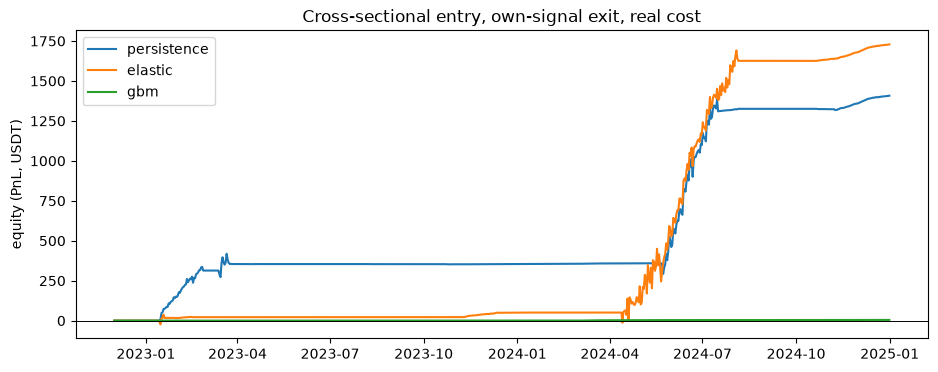

,final_pnl,sharpe,fees,funding_net,pnl_2023,pnl_2024
model,,,,,,
persistence,1408.07,2.21,208.64,1488.06,353.99,1053.66
elastic,1729.05,1.72,143.55,1821.22,50.03,1678.64
gbm,4.41,4.84,0.10,4.32,0.00,4.41


In [18]:
SIDS = [NAME_TO_ID[s] for s in SYMBOLS]
HURDLE_H, EXIT_H, TOP_N_H = 0.0034, 0.0, 3


class PredCrossSectionalHold:
    """Cross-sectional entry, own-signal exit. Fill up to top_n slots with the
    best predictions that clear the hurdle, then hold each name until its own
    prediction falls to the exit level. Ranking only gates entry, a held name
    is never dropped for being out-ranked."""

    def __init__(self, bt, pred, sids, qty=1.0, hurdle=0.0034, exit=0.0, top_n=3):
        self.bt = bt
        self.pred = pred
        self.sids = sids
        self.qty = qty
        self.hurdle = hurdle
        self.exit = exit
        self.top_n = top_n
        self.hits = 0
        self.misses = 0

    def on_event(self, ev):
        if ev.kind != qb.EventKind.Funding or ev.venue != FUT:
            return None
        ts = ev.ts
        p = self.pred.get((ev.symbol, ts))
        if p is None:
            self.misses += 1
            return None
        self.hits += 1

        if self.bt.position(ev.symbol, SPOT) > 0:
            # Held. Exit only on this name's own signal.
            target = 0.0 if p <= self.exit else self.qty
        else:
            # Flat. Take a free slot only if this name is among the best
            # eligible flat names for the slots that are open.
            held = sum(1 for s in self.sids if self.bt.position(s, SPOT) > 0)
            free = self.top_n - held
            if free <= 0:
                target = 0.0
            else:
                cand = [(self.pred[(s, ts)], s) for s in self.sids
                        if self.bt.position(s, SPOT) <= 0
                        and (s, ts) in self.pred and self.pred[(s, ts)] >= self.hurdle]
                cand.sort(reverse=True)
                winners = {s for _, s in cand[:free]}
                target = self.qty if ev.symbol in winners else 0.0

        return [qb.Intent(ev.symbol, SPOT, target),
                qb.Intent(ev.symbol, FUT, -target)]

    def on_timer(self, now):
        return None


xhold = {}
for col in SOURCES:
    pm = pred_map(col, SYMBOLS)
    o = run_backtest(
        SYMBOLS,
        lambda bt, pm=pm: PredCrossSectionalHold(bt, pm, SIDS, 1.0, HURDLE_H, EXIT_H, TOP_N_H))
    xhold[col.replace("pred_", "")] = o
    log_run(f"xhold_{col.replace('pred_', '')}",
            {"rule": "xhold", "pred_col": col, "hurdle": HURDLE_H, "exit": EXIT_H,
             "top_n": TOP_N_H}, o)

display(compare(xhold, "Cross-sectional entry, own-signal exit, real cost"))

Churn's gone, that fixed it. Fees collapse from thousands to basically nothing, 209 for persistence and 0.1 for gbm, and pnl flips positive. Holding on the name's own signal instead of the ranking stops the rotation dead.

But now the slots lock up. Exit at zero means a name almost never leaves, so the three slots fill early in 2023 and freeze. When BTC's big 2024 funding shows up there is no free slot for it. gbm is the extreme, it froze on three 2023 picks and made 4 quid, never touched the 2024 run. elastic caught 1640 of BTC's funding against 6974 if we just hold it.

persistence does best here only because it is noisy enough to keep exiting and freeing slots, so it rotates into BTC sometimes. wrong reason again.

So we swapped rotation churn for a frozen book. The edge is being in BTC, and a three slot cap keeps missing it.

## Cross-sectional slot count sweep

The same entry-and-hold rule, sweeping the number of slots from three up to ten. Ten slots is no cap, hold every name that clears the hurdle, which is just the fixed threshold on the whole book. Read where the slot count stops mattering, that is the point where selection adds nothing over holding everything eligible.

In [19]:
TOP_NS = [3, 5, 7, 10]

xn_rows = []
for col in SOURCES:
    name = col.replace("pred_", "")
    pm = pred_map(col, SYMBOLS)
    for N in TOP_NS:
        o = run_backtest(
            SYMBOLS,
            lambda bt, pm=pm, N=N: PredCrossSectionalHold(bt, pm, SIDS, 1.0, 0.0034, 0.0, N))
        xn_rows.append({"model": name, "top_n": N,
                        "pnl": round(o["final_equity"], 1),
                        "sharpe": round(daily_sharpe(o["equity"]), 2),
                        "fees": round(o["attr"]["fees"].sum(), 1)})

xn = pd.DataFrame(xn_rows)
print("PnL  (rows top_n, cols model)")
display(xn.pivot(index="top_n", columns="model", values="pnl"))
print("Sharpe")
display(xn.pivot(index="top_n", columns="model", values="sharpe"))
print("fees")
display(xn.pivot(index="top_n", columns="model", values="fees"))

PnL  (rows top_n, cols model)


model,elastic,gbm,persistence
top_n,,,
3,1729.0,4.4,1408.1
5,3993.1,4213.0,3581.9
7,4151.5,4559.6,8543.4
10,7489.0,6664.4,8580.0


Sharpe


model,elastic,gbm,persistence
top_n,,,
3,1.72,4.84,2.21
5,3.10,2.62,3.48
7,3.23,2.79,4.98
10,4.15,3.66,4.97


fees


model,elastic,gbm,persistence
top_n,,,
3,143.5,0.1,208.6
5,206.9,96.1,273.8
7,212.1,103.8,359.7
10,275.6,171.3,380.1


More slots more money, straight line up. Ten slots is no cap and it lands right on the fixed threshold, 7489 elastic, 6664 gbm, 8580 persistence, same numbers. No sweet spot in the middle, every slot taken away just removes exposure to the names that pay. So capping is pure loss here. Fees stay tiny the whole way so the hold design is fine, it is the cap that is the problem. gbm at three slots shows a fake 4.84 Sharpe, that is 4 quid held dead flat, ignore it.

## What we learned

The carry is real but thin and one-note. About 85 percent BTC and about 90 percent 2024, the high-funding bull. 2022 and 2023 are basically flat. It is a BTC 2024 funding harvest, not a broad edge.

Turnover is the whole game. Every shape wins or loses on how much it trades. Trade little and it works, fixed threshold and slow partial adjustment. Trade more and it bleeds, hysteresis, cross-sectional rotation, fast adjustment, equal notional sizing.

The model barely matters. Where it does, gbm wins because it is the smoothest signal so it churns least, not because it is more accurate. persistence wins the quietest rule and loses anywhere we trade on its noise.

Picking symbols does not help. Funding is additive and sits in BTC, so holding everything above the hurdle beats holding a chosen few. More slots just meant more money up to no cap, which is the fixed threshold. Cross-sectional is a dead end here.

The Sharpe is soft, 4 to 5, flattered by funding being autocorrelated, no liquidation in the sim, and one regime doing all the work.

Best two. Partial adjustment on gbm run slow, most money, about 9800. Fixed threshold on persistence, best Sharpe, cleaner, less money.

## Adaptive partial adjustment

Same partial adjustment, but the drift fraction is no longer one number. Each symbol and print gets its own adjust from the prediction's trailing signal to noise, the level over the print-to-print wobble, so it drifts faster where the signal is clean and slower where it is jumpy. Clipped to a band around the fixed sweep's best.

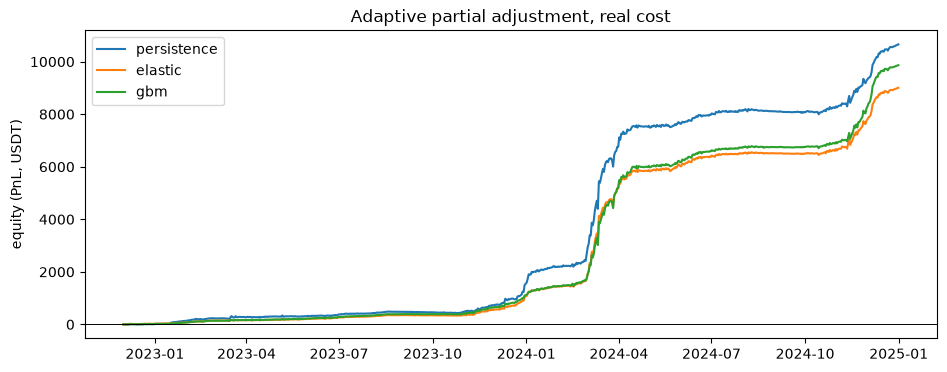

,final_pnl,sharpe,fees,funding_net,pnl_2023,pnl_2024
model,,,,,,
persistence,10657.61,3.87,2908.09,13038.23,1531.54,9070.27
elastic,9006.48,3.79,2153.08,10726.21,1035.66,7922.92
gbm,9867.01,4.18,1358.07,10803.28,1096.92,8739.62


In [20]:
def build_adjust_map(col, window=24, adj_min=0.05, adj_max=0.5, mid=0.15):
    d = oof[["sid", "ts_ns", col]].sort_values(["sid", "ts_ns"]).copy()
    d["chg"] = d.groupby("sid")[col].diff()
    d["noise"] = d.groupby("sid")["chg"].transform(
        lambda x: x.rolling(window, min_periods=6).std())
    d["snr"] = d[col].abs() / (d["noise"] + 1e-9)
    ref = d["snr"].median()
    d["adj"] = (mid * d["snr"] / ref).clip(adj_min, adj_max).fillna(mid)
    return dict(zip(zip(d["sid"], d["ts_ns"]), d["adj"]))


class PredAdaptivePartial:
    """Partial adjustment with a per-symbol per-print drift fraction, taken
    from the prediction's trailing signal to noise. One lookup per event."""

    def __init__(self, bt, pred, adj_map, hurdle=0.0034, cap=2.0, adj_default=0.15):
        self.bt = bt
        self.pred = pred
        self.adj_map = adj_map
        self.hurdle = hurdle
        self.cap = cap
        self.adj_default = adj_default
        self.hits = 0
        self.misses = 0

    def on_event(self, ev):
        if ev.kind != qb.EventKind.Funding or ev.venue != FUT:
            return None
        p = self.pred.get((ev.symbol, ev.ts))
        if p is None:
            self.misses += 1
            return None
        self.hits += 1
        aim = float(np.clip(p / self.hurdle, 0.0, self.cap))
        adj = self.adj_map.get((ev.symbol, ev.ts), self.adj_default)
        cur = self.bt.position(ev.symbol, SPOT)
        target = cur + adj * (aim - cur)
        return [qb.Intent(ev.symbol, SPOT, target),
                qb.Intent(ev.symbol, FUT, -target)]

    def on_timer(self, now):
        return None


adaptive = {}
for col in SOURCES:
    pm = pred_map(col, SYMBOLS)
    am = build_adjust_map(col)
    o = run_backtest(SYMBOLS,
                     lambda bt, pm=pm, am=am: PredAdaptivePartial(bt, pm, am, 0.0034, 2.0))
    adaptive[col.replace("pred_", "")] = o
    log_run(f"adaptive_{col.replace('pred_', '')}",
            {"rule": "adaptive", "pred_col": col, "cap": 2.0}, o)

display(compare(adaptive, "Adaptive partial adjustment, real cost"))

Roughly a wash. Letting the drift speed up where the signal is clean and slow where it is noisy barely moves it, persistence up a bit to 10.7k, elastic down a touch, gbm flat, Sharpe mostly the same or slightly worse.

Makes sense. The sweep already said slower is better everywhere, so giving it room to go faster mostly just adds fees for a little more funding. Median adjust is still 0.15, the band 0.05 to 0.5 just wobbles around it. persistence is the one that gains, its clean stretches let it speed up, wrong-reason winner again since it was the noisy one.

Real point, the adaptive idea is right but cost gates it. At taker costs the optimum is slow everywhere so there is nothing to adapt into. Cut the cost with maker and the optimal speed rises, then this has room to matter. Park it until maker is in.